In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
while not (ROOT / "src").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

import h5py
import matplotlib.pyplot as plt
import numpy as np

import brighteyes_flim.tools_phasor as flim
import brighteyes_ism.analysis.Graph_lib as gra
import brighteyes_ism.dataio.mcs as mcs
from scipy.ndimage import shift
from skimage.registration import phase_cross_correlation
from brighteyes_flim import calibrate_h5_file, show_h5_structure_html, sum_channel_applying_shifts, Alignment




In [2]:
TAU_REF = None  # Let the algorithm estimate the reference lifetime directly from the reference data.
CHANNEL_SKEW_TYPE = "phase_cross_correlation"
CHANNEL_SKEW_SOURCE = "irf"
CHANNEL_SKEW_FIT_REFERENCE_CHANNEL = 12
CHANNEL_SKEW_FIT_UPSAMPLING = 10
CHANNEL_SKEW_FIT_APODIZE = False
# CHANNEL_SKEW_SOURCE = np.array(custom_skew_bins, dtype=float)
# If a custom skew array is used, its length must match the calibrated channel count.
OVERWRITE = True

LASER_PERIOD_NS = None
#filename = 

DATA_CALIBRATE = "/mnt/DATA/Mixed Data/lamina+tubulin/data-10-04-2024-19-27-47_calib.h5"


In [3]:
show_h5_structure_html(DATA_CALIBRATE)

'<div class="h5-tree">\n  <style>\n    .h5-tree {\n      color-scheme: light dark;\n      font-family: "Menlo", "Consolas", "DejaVu Sans Mono", monospace;\n      font-size: 13px;\n      line-height: 1.5;\n      color: var(--h5-fg);\n      --h5-fg: #1f2937;\n      --h5-muted: #6b7280;\n      --h5-border: #d1d5db;\n      --h5-group: #0f766e;\n      --h5-dataset: #1d4ed8;\n      --h5-attrs: #7c2d12;\n      --h5-node-ref: #7c3aed;\n      --h5-attr-key: #b45309;\n      --h5-attr-value: #374151;\n      --h5-root: #111827;\n    }\n    @media (prefers-color-scheme: dark) {\n      .h5-tree {\n        --h5-fg: #e5e7eb;\n        --h5-muted: #9ca3af;\n        --h5-border: #4b5563;\n        --h5-group: #5eead4;\n        --h5-dataset: #93c5fd;\n        --h5-attrs: #fdba74;\n        --h5-node-ref: #c4b5fd;\n        --h5-attr-key: #fbbf24;\n        --h5-attr-value: #f3f4f6;\n        --h5-root: #f9fafb;\n      }\n    }\n    .h5-tree ul {\n      list-style: none;\n      margin: 0.2rem 0 0.2rem 1.1rem;\n

In [4]:
hf=h5py.File(DATA_CALIBRATE, "r")
laser_freq_mhz = float(hf["calibration/data"].attrs["laser_freq_in_mhz"]) 
laser_period_ns = float(hf["calibration/data"].attrs["laser_period_in_ns"])
rangex = hf['configurationGUI'].attrs['range_x']
nx = hf['configurationGUI'].attrs['nx']
pixel_size_x_um= rangex / nx
nbin = hf['configurationGUI'].attrs['timebin_per_pixel']
dt = hf['configurationGUI'].attrs['time_resolution']
pxdwelltime = dt * nbin


laser_freq_mhz = float(hf["calibration/data"].attrs["laser_freq_in_mhz"]) 
laser_period_ns = float(hf["calibration/data"].attrs["laser_period_in_ns"])
rangex = hf['configurationGUI'].attrs['range_x']
nx = hf['configurationGUI'].attrs['nx']
pixel_size_x_um= rangex / nx
nbin = hf['configurationGUI'].attrs['timebin_per_pixel']
dt = hf['configurationGUI'].attrs['time_resolution']
pxdwelltime = dt * nbin

print(f"Using calibrated laser timing: {laser_freq_mhz :.4f} MHz ({laser_period_ns:.4f} ns)")

print(hf.keys())
data_input = hf["data"][:]  # Per-pixel decay histograms, aligned to the excitation timing reference.
channel_skew = hf["calibration/data/channel_skew"][:]
common_delay_in_bins = hf["calibration/data/common_delay_in_bins"][:]
irf_common_delay_realigned = hf["calibration/data/irf_common_delay_realigned"][:]

print(data_input.shape)
data_summed_no_alignment = np.sum(data_input,axis=(0,1,2,3,5))
irf_summed_no_alignment = irf_common_delay_realigned.sum(axis=-1)

data_summed = sum_channel_applying_shifts(data_input, channel_skew, axis=())[0, 0,...]
irf_summed = sum_channel_applying_shifts(irf_common_delay_realigned, channel_skew, axis=())

data_summed_rev = sum_channel_applying_shifts(data_input, channel_skew, axis=(), reverse_shifts=False)[0, 0,...]
irf_summed_rev = sum_channel_applying_shifts(irf_common_delay_realigned, channel_skew, axis=(), reverse_shifts=False)



print(data_summed.shape)
print(irf_summed.shape)
print("Channel skew correction applied.")


Using calibrated laser timing: 41.4800 MHz (24.1080 ns)
<KeysViewHDF5 ['calibration', 'configurationFPGA', 'configurationGUI', 'configurationGUI_beforeStart', 'configurationSpadFCSmanager', 'data', 'data_channels_extra']>
(1, 1, 1250, 1250, 81, 25)
(1250, 1250, 81)
(81,)
Channel skew correction applied.


In [5]:
data_summed.shape

(1250, 1250, 81)

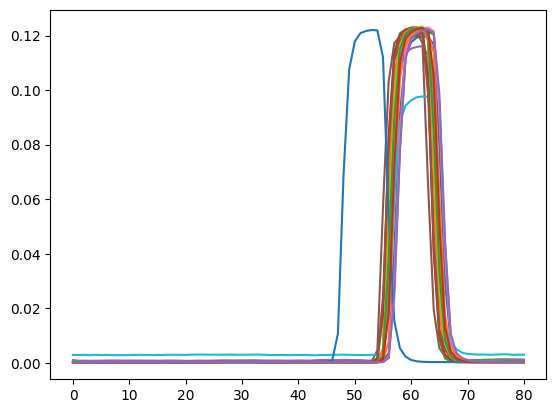

In [6]:
irf_shifted = hf["calibration/data/irf_common_delay_realigned"]
data = hf["data"][0,0,:,:,:,:]
irf_shifted.shape, data.shape
plt.plot(irf_shifted)

In [7]:
t = laser_period_ns *np.arange(0,nbin) / nbin
t

array([ 0.        ,  0.29762968,  0.59525935,  0.89288903,  1.19051871,
        1.48814839,  1.78577806,  2.08340774,  2.38103742,  2.6786671 ,
        2.97629677,  3.27392645,  3.57155613,  3.8691858 ,  4.16681548,
        4.46444516,  4.76207484,  5.05970451,  5.35733419,  5.65496387,
        5.95259355,  6.25022322,  6.5478529 ,  6.84548258,  7.14311225,
        7.44074193,  7.73837161,  8.03600129,  8.33363096,  8.63126064,
        8.92889032,  9.22651999,  9.52414967,  9.82177935, 10.11940903,
       10.4170387 , 10.71466838, 11.01229806, 11.30992774, 11.60755741,
       11.90518709, 12.20281677, 12.50044644, 12.79807612, 13.0957058 ,
       13.39333548, 13.69096515, 13.98859483, 14.28622451, 14.58385419,
       14.88148386, 15.17911354, 15.47674322, 15.77437289, 16.07200257,
       16.36963225, 16.66726193, 16.9648916 , 17.26252128, 17.56015096,
       17.85778064, 18.15541031, 18.45303999, 18.75066967, 19.04829934,
       19.34592902, 19.6435587 , 19.94118838, 20.23881805, 20.53

In [8]:

'''
def perform_fit_data(
    t,
    data,
    irf,
    period,
    initial_tau=None,
    initial_dT=None,
    initial_C=None,
    irf_min=1e-5,
    mode="irf_shift",
    fit_type="circular",
    force_C_normalized=False,
):
'''  

'\ndef perform_fit_data(\n    t,\n    data,\n    irf,\n    period,\n    initial_tau=None,\n    initial_dT=None,\n    initial_C=None,\n    irf_min=1e-5,\n    mode="irf_shift",\n    fit_type="circular",\n    force_C_normalized=False,\n):\n'

In [9]:
data_px=data_summed[1016,1225,:]
data_px.shape


(81,)

In [10]:
data_px.shape, irf_summed.shape

((81,), (81,))

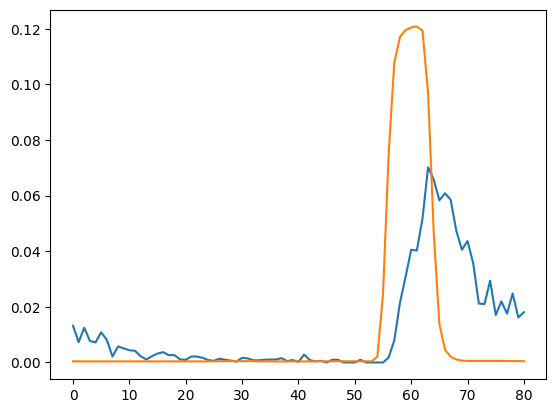

In [11]:
plt.plot(data_px/data_px.sum())
plt.plot(irf_summed/irf_summed.sum())

In [12]:
t

array([ 0.        ,  0.29762968,  0.59525935,  0.89288903,  1.19051871,
        1.48814839,  1.78577806,  2.08340774,  2.38103742,  2.6786671 ,
        2.97629677,  3.27392645,  3.57155613,  3.8691858 ,  4.16681548,
        4.46444516,  4.76207484,  5.05970451,  5.35733419,  5.65496387,
        5.95259355,  6.25022322,  6.5478529 ,  6.84548258,  7.14311225,
        7.44074193,  7.73837161,  8.03600129,  8.33363096,  8.63126064,
        8.92889032,  9.22651999,  9.52414967,  9.82177935, 10.11940903,
       10.4170387 , 10.71466838, 11.01229806, 11.30992774, 11.60755741,
       11.90518709, 12.20281677, 12.50044644, 12.79807612, 13.0957058 ,
       13.39333548, 13.69096515, 13.98859483, 14.28622451, 14.58385419,
       14.88148386, 15.17911354, 15.47674322, 15.77437289, 16.07200257,
       16.36963225, 16.66726193, 16.9648916 , 17.26252128, 17.56015096,
       17.85778064, 18.15541031, 18.45303999, 18.75066967, 19.04829934,
       19.34592902, 19.6435587 , 19.94118838, 20.23881805, 20.53

In [13]:
res=Alignment.perform_fit_data(
    t=t,
    data=data_px,
    irf=irf_summed,
    period=laser_period_ns,
    initial_tau=1,
    initial_dT=1,
    initial_C=1,
    mode="irf_shift",
    fit_type="circular",
    force_C_normalized=True,
)
res

({'C': np.float64(1.0),
  'dT': np.float64(0.2079406355416893),
  'tau': np.float64(2.5906116094597125)},
 array([[        nan,         nan,         nan],
        [        nan,  0.02266099, -0.00649968],
        [        nan, -0.00649968,  0.00686938]]))

In [14]:
import numpy as np
from joblib import Parallel, delayed
from tqdm.auto import tqdm


# -----------------------------
# User parameters
# -----------------------------

initial_tau = 1.0
initial_dT = 1.0
initial_C = 1.0

mode = "irf_shift"
fit_type = "circular"
force_C_normalized = True

# Number of parallel workers.
# Use -1 for all cores, or set e.g. 8.
n_jobs = -1


# -----------------------------
# Basic checks
# -----------------------------

data_summed = np.asarray(data_summed, dtype=float)
irf_summed = np.asarray(irf_summed, dtype=float)
t = np.asarray(t, dtype=float)

if data_summed.ndim != 3:
    raise ValueError(f"data_summed must have shape (ny, nx, nbins), got {data_summed.shape}")

ny, nx, nbins = data_summed.shape

if irf_summed.shape != (nbins,):
    raise ValueError(f"irf_summed must have shape ({nbins},), got {irf_summed.shape}")

if t.shape != (nbins,):
    raise ValueError(f"t must have shape ({nbins},), got {t.shape}")

if not np.all(np.isfinite(irf_summed)) or irf_summed.sum() <= 0:
    raise ValueError("irf_summed contains invalid values or has non-positive sum")

if not np.all(np.isfinite(t)):
    raise ValueError("t contains invalid values")


# -----------------------------
# Output maps
# -----------------------------

C_map = np.full((ny, nx), np.nan, dtype=float)
dT_map = np.full((ny, nx), np.nan, dtype=float)
tau_map = np.full((ny, nx), np.nan, dtype=float)

C_err_map = np.full((ny, nx), np.nan, dtype=float)
dT_err_map = np.full((ny, nx), np.nan, dtype=float)
tau_err_map = np.full((ny, nx), np.nan, dtype=float)


# -----------------------------
# Pixel mask
# -----------------------------

data_flat = data_summed.reshape(-1, nbins)

valid_mask = (
    np.all(np.isfinite(data_flat), axis=1)
    & (np.sum(data_flat, axis=1) > 0)
)

valid_indices = np.flatnonzero(valid_mask)

print(f"Valid pixels: {len(valid_indices)} / {ny * nx}")


# -----------------------------
# Single-pixel fit function
# -----------------------------

def fit_one_pixel(flat_idx):
    y = flat_idx // nx
    x = flat_idx % nx

    hist = data_summed[y, x, :]

    try:
        res = Alignment.perform_fit_data(
            t=t,
            data=hist,
            irf=irf_summed,
            period=laser_period_ns,
            initial_tau=initial_tau,
            initial_dT=initial_dT,
            initial_C=initial_C,
            mode=mode,
            fit_type=fit_type,
            force_C_normalized=force_C_normalized,
        )

        fit_res, cov = res

        C = float(fit_res["C"])
        dT = float(fit_res["dT"])
        tau = float(fit_res["tau"])

        diag = np.diag(cov)

        # Errors are sqrt of covariance diagonal.
        # With force_C_normalized=True, C is fixed, so C_err is usually NaN.
        C_err = np.sqrt(diag[0]) if diag.size > 0 and np.isfinite(diag[0]) and diag[0] >= 0 else np.nan
        dT_err = np.sqrt(diag[1]) if diag.size > 1 and np.isfinite(diag[1]) and diag[1] >= 0 else np.nan
        tau_err = np.sqrt(diag[2]) if diag.size > 2 and np.isfinite(diag[2]) and diag[2] >= 0 else np.nan

        return flat_idx, C, dT, tau, C_err, dT_err, tau_err

    except Exception:
        return flat_idx, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan


# -----------------------------
# Parallel execution
# -----------------------------

results = Parallel(
    n_jobs=n_jobs,
    backend="loky",
    verbose=0,
)(
    delayed(fit_one_pixel)(idx)
    for idx in tqdm(valid_indices, desc="Fitting pixels")
)


# -----------------------------
# Fill maps
# -----------------------------

for flat_idx, C, dT, tau, C_err, dT_err, tau_err in results:
    y = flat_idx // nx
    x = flat_idx % nx

    C_map[y, x] = C
    dT_map[y, x] = dT
    tau_map[y, x] = tau

    C_err_map[y, x] = C_err
    dT_err_map[y, x] = dT_err
    tau_err_map[y, x] = tau_err


# -----------------------------
# Compact outputs
# -----------------------------

fit_maps = {
    "C": C_map,
    "dT": dT_map,
    "tau": tau_map,
    "C_err": C_err_map,
    "dT_err": dT_err_map,
    "tau_err": tau_err_map,
}

fit_stack = np.stack(
    [
        C_map,
        dT_map,
        tau_map,
        C_err_map,
        dT_err_map,
        tau_err_map,
    ],
    axis=0,
)

fit_stack_names = [
    "C",
    "dT",
    "tau",
    "C_err",
    "dT_err",
    "tau_err",
]

print("Done.")
print("fit_stack shape:", fit_stack.shape)
print("fit_stack axis 0:", fit_stack_names)

Valid pixels: 1562500 / 1562500


Fitting pixels:   0%|          | 0/1562500 [00:00<?, ?it/s]

Done.
fit_stack shape: (6, 1250, 1250)
fit_stack axis 0: ['C', 'dT', 'tau', 'C_err', 'dT_err', 'tau_err']


In [15]:
tau=fit_maps["tau"]

(array([2.00000e+00, 1.00000e+00, 4.00000e+00, 8.00000e+00, 2.10000e+01,
        7.70000e+01, 3.13000e+02, 2.11500e+03, 1.90650e+04, 1.29441e+05,
        3.75598e+05, 4.46314e+05, 3.48657e+05, 1.59205e+05, 4.52520e+04,
        1.41980e+04, 6.24500e+03, 3.85700e+03, 2.65300e+03, 2.04000e+03,
        1.61200e+03, 1.23500e+03, 1.07900e+03, 7.61000e+02, 6.25000e+02,
        5.35000e+02, 3.82000e+02, 3.03000e+02, 1.89000e+02, 1.61000e+02,
        1.15000e+02, 9.10000e+01, 8.00000e+01, 5.20000e+01, 3.80000e+01,
        3.40000e+01, 2.80000e+01, 1.80000e+01, 2.20000e+01, 1.30000e+01,
        6.00000e+00, 1.00000e+01, 9.00000e+00, 2.00000e+00, 8.00000e+00,
        4.00000e+00, 6.00000e+00, 1.00000e+00, 1.00000e+00, 2.00000e+00,
        3.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 2.00000e+00,
        1.00000e+00, 0.00000e+00, 1.00000e+00, 1.00000e+00, 0.00000e+00,
        0.00000e+00, 0.00000e+00, 0.00000e+00, 2.00000e+00, 0.00000e+00,
        0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00

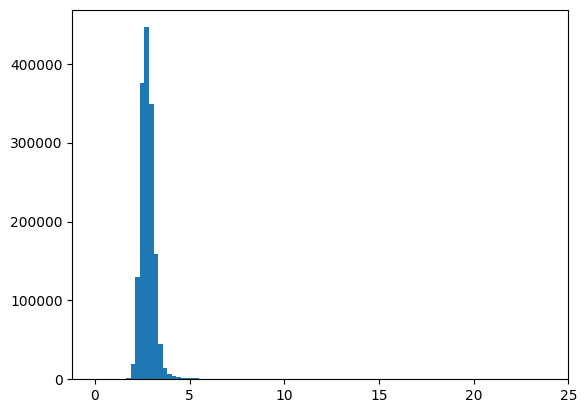

In [16]:
plt.hist(tau.flatten(),bins=100)

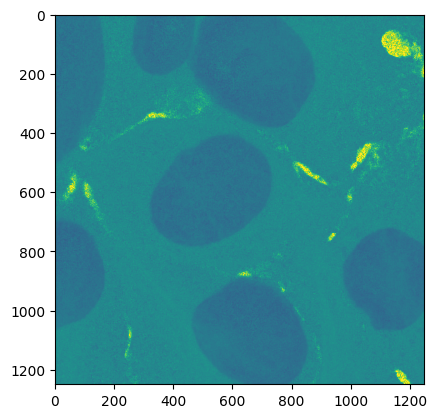

In [17]:
plt.imshow(tau,vmin=1,vmax=5)

In [18]:
import brighteyes_ism.analysis.Graph_lib as gra


In [19]:
intensity=data.sum(axis=(-1,-2))

(<Figure size 640x480 with 2 Axes>, <Axes: >)

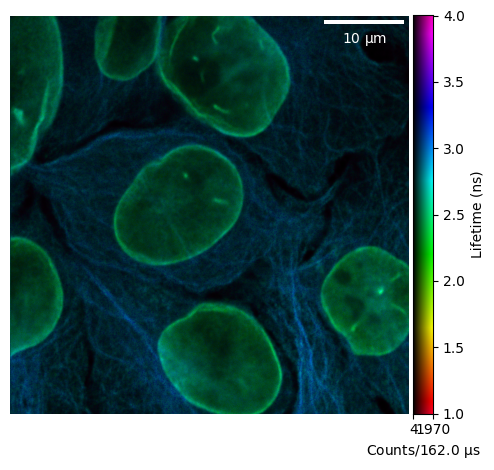

In [21]:


gra.show_flim(intensity, tau,pxsize=pixel_size_x_um, pxdwelltime=pxdwelltime,lifetime_bounds=[1,4])
